# Blood Cell Anomaly Detection

**Machine Learning Classification Project**

This project explores a blood-cell dataset and builds machine learning models to classify cells as:

- **0 → Normal**
- **1 → Abnormal**

The workflow covers data understanding, cleaning, encoding, outlier inspection, exploratory data analysis, preprocessing, model training, evaluation, and model comparison.

## 1. Import Libraries

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)


## 2. Load the Dataset

Load the blood cell anomaly detection dataset and display the first few rows.

In [87]:
df = pd.read_csv('/content/blood_cell_anomaly_detection.csv')
df.head()

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


## 3. Data Understanding

Check the basic information of the dataset: shape, data types, statistical summary, missing values, and duplicates.

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   cell_id                                  5880 non-null   object 
 1   cell_type                                5880 non-null   object 
 2   anomaly_label                            5880 non-null   int64  
 3   disease_category                         5880 non-null   object 
 4   cell_diameter_um                         5880 non-null   float64
 5   nucleus_area_pct                         5880 non-null   float64
 6   chromatin_density                        5880 non-null   float64
 7   cytoplasm_ratio                          5880 non-null   float64
 8   circularity                              5880 non-null   float64
 9   eccentricity                             5880 non-null   float64
 10  granularity_score                        5880 no

In [89]:
df.shape

(5880, 36)

In [90]:
df.describe()

,anomaly_label,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,...,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,...,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.319728,10.176267,43.537976,0.391394,0.564173,0.769263,0.365458,1.882109,1.769252,0.842866,...,13.547194,41.021956,249792.623469,88.942211,33.495867,76.006803,336.235374,0.317583,0.853243,0.866370
std,0.466411,3.642051,33.419390,0.310006,0.335282,0.158219,0.201501,1.428336,1.229362,0.096033,...,2.025136,5.484636,79472.676228,9.927005,1.480168,25.032178,111.922015,0.349655,0.106589,0.094065
min,0.000000,1.000000,0.000000,0.000000,0.050000,0.100000,0.000000,0.000000,1.000000,0.290000,...,5.400000,20.300000,20000.000000,60.000000,28.000000,40.000000,224.000000,0.000000,0.417300,0.471700
25%,0.000000,7.630000,0.000000,0.000000,0.276000,0.711000,0.214750,0.670000,1.000000,0.784000,...,12.200000,37.300000,194653.250000,82.300000,32.500000,60.000000,224.000000,0.063675,0.799000,0.817250
50%,0.000000,10.055000,54.500000,0.479500,0.452000,0.805000,0.331000,1.320000,1.000000,0.854000,...,13.500000,41.000000,250070.500000,88.900000,33.500000,100.000000,256.000000,0.113150,0.877450,0.883400
75%,1.000000,12.860000,72.300000,0.635000,1.000000,0.879000,0.456000,2.980000,2.300000,0.918000,...,14.900000,44.800000,303863.500000,95.700000,34.500000,100.000000,360.000000,0.743850,0.929350,0.934000
max,1.000000,21.180000,99.000000,1.000000,1.000000,1.000000,0.990000,6.000000,7.200000,1.000000,...,20.000000,60.000000,543084.000000,120.000000,38.000000,100.000000,512.000000,1.000000,1.000000,1.000000


In [91]:
df.isnull().sum()

,0
cell_id,0
cell_type,0
anomaly_label,0
disease_category,0
cell_diameter_um,0
nucleus_area_pct,0
chromatin_density,0
cytoplasm_ratio,0
circularity,0
eccentricity,0


In [92]:
df.duplicated().sum()

np.int64(0)

## 4. Target Distribution

Analyze the distribution of the target variable `anomaly_label` to understand class balance.

In [93]:
df['anomaly_label'].value_counts()

,count
anomaly_label,
0,4000
1,1880


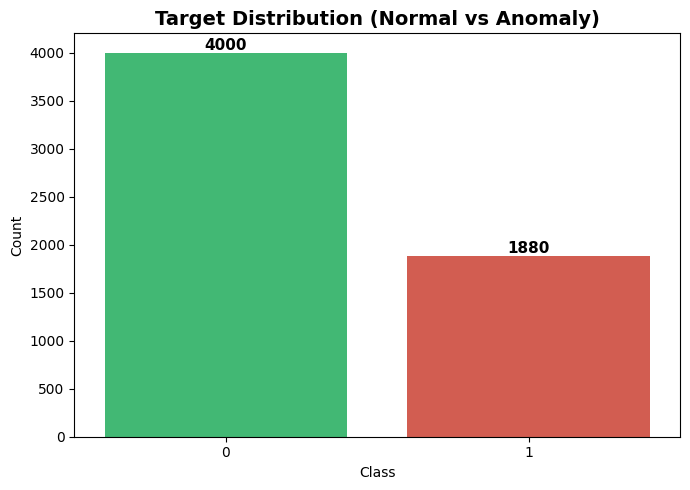

In [94]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='anomaly_label', palette=['#2ecc71', '#e74c3c'])
plt.title('Target Distribution (Normal vs Anomaly)', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Feature Selection and Data Cleaning

Remove columns that cause data leakage or are metadata only:

- `cell_id` → identifier only
- `disease_category` → directly determines the target (leakage)
- `cell_type` → excluded from this modeling workflow
- `dataset_source`, `staining_protocol`, `microscope_model` → collection metadata
- `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`, `labeller_confidence_score` → target-derived / annotation metadata

In [95]:
df_clean = df.drop([
    'cell_id',
    'cell_type',
    'disease_category',
    'dataset_source',
    'staining_protocol',
    'microscope_model',
    'cytodiffusion_anomaly_score',
    'cytodiffusion_classification_confidence',
    'labeller_confidence_score'
], axis=1)

print("Shape after cleaning:", df_clean.shape)
df_clean.head()

Shape after cleaning: (5880, 27)


,anomaly_label,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,...,patient_sex,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,magnification_x,image_resolution_px
0,1,15.18,58.8,0.542,0.301,0.563,0.529,4.11,6.6,0.800,...,F,6352,4.44,11.7,43.4,257383,85.5,31.4,100,224
1,1,16.47,73.6,0.583,0.365,0.859,0.443,2.50,6.3,0.737,...,M,7709,4.90,13.9,42.2,302274,92.5,35.0,100,224
2,0,13.41,55.5,0.448,0.376,0.781,0.407,3.01,3.2,0.790,...,M,7451,5.72,16.1,39.2,229996,76.3,33.0,100,512
3,0,7.36,0.0,0.000,1.000,0.880,0.167,0.43,1.0,0.937,...,F,9196,3.42,14.6,54.1,130720,92.3,32.5,100,512
4,0,7.53,0.0,0.000,1.000,1.000,0.158,0.51,1.0,0.925,...,M,5898,5.36,14.6,36.7,228652,83.9,33.4,100,224


## 6. Encode Categorical Features

Encode categorical columns into numeric values:

- `patient_sex`: **F → 0** , **M → 1**
- `patient_age_group`: **Pediatric → 0** , **Adult → 1** , **Elderly → 2**

In [96]:
df.select_dtypes(include='object').columns.tolist()

['cell_id',
 'cell_type',
 'disease_category',
 'patient_age_group',
 'patient_sex',
 'dataset_source',
 'staining_protocol',
 'microscope_model']

In [97]:
df_clean['patient_age_group'] = df_clean['patient_age_group'].map({
    'Pediatric': 0,
    'Adult': 1,
    'Elderly': 2
})

df_clean['patient_sex'] = df_clean['patient_sex'].map({
    'F': 0,
    'M': 1
})

df_clean[['patient_sex', 'patient_age_group']].head()

,patient_sex,patient_age_group
0,0,2
1,1,2
2,1,1
3,0,1
4,1,2


## 7. Define Feature Order

Define an explicit and fixed order of the 26 features.  
This order must be used consistently during training and deployment.

In [98]:
FEATURE_ORDER = [
    'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density',
    'cytoplasm_ratio', 'circularity', 'eccentricity',
    'granularity_score', 'lobularity_score', 'membrane_smoothness',
    'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b',
    'stain_intensity', 'wbc_count_per_ul', 'rbc_count_millions_per_ul',
    'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul',
    'mcv_fl', 'mchc_g_dl', 'magnification_x', 'image_resolution_px',
    'patient_age_group', 'patient_sex'
]

df_clean = df_clean[FEATURE_ORDER + ['anomaly_label']]
print("Number of features:", len(FEATURE_ORDER))
df_clean.head()

Number of features: 26


,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,...,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,magnification_x,image_resolution_px,patient_age_group,patient_sex,anomaly_label
0,15.18,58.8,0.542,0.301,0.563,0.529,4.11,6.6,0.800,445,...,11.7,43.4,257383,85.5,31.4,100,224,2,0,1
1,16.47,73.6,0.583,0.365,0.859,0.443,2.50,6.3,0.737,383,...,13.9,42.2,302274,92.5,35.0,100,224,2,1,1
2,13.41,55.5,0.448,0.376,0.781,0.407,3.01,3.2,0.790,418,...,16.1,39.2,229996,76.3,33.0,100,512,1,1,0
3,7.36,0.0,0.000,1.000,0.880,0.167,0.43,1.0,0.937,217,...,14.6,54.1,130720,92.3,32.5,100,512,1,0,0
4,7.53,0.0,0.000,1.000,1.000,0.158,0.51,1.0,0.925,147,...,14.6,36.7,228652,83.9,33.4,100,224,2,1,0


## 8. Exploratory Data Analysis - Feature Distributions

Visualize the distribution of key morphological and lab features to understand the data shape.

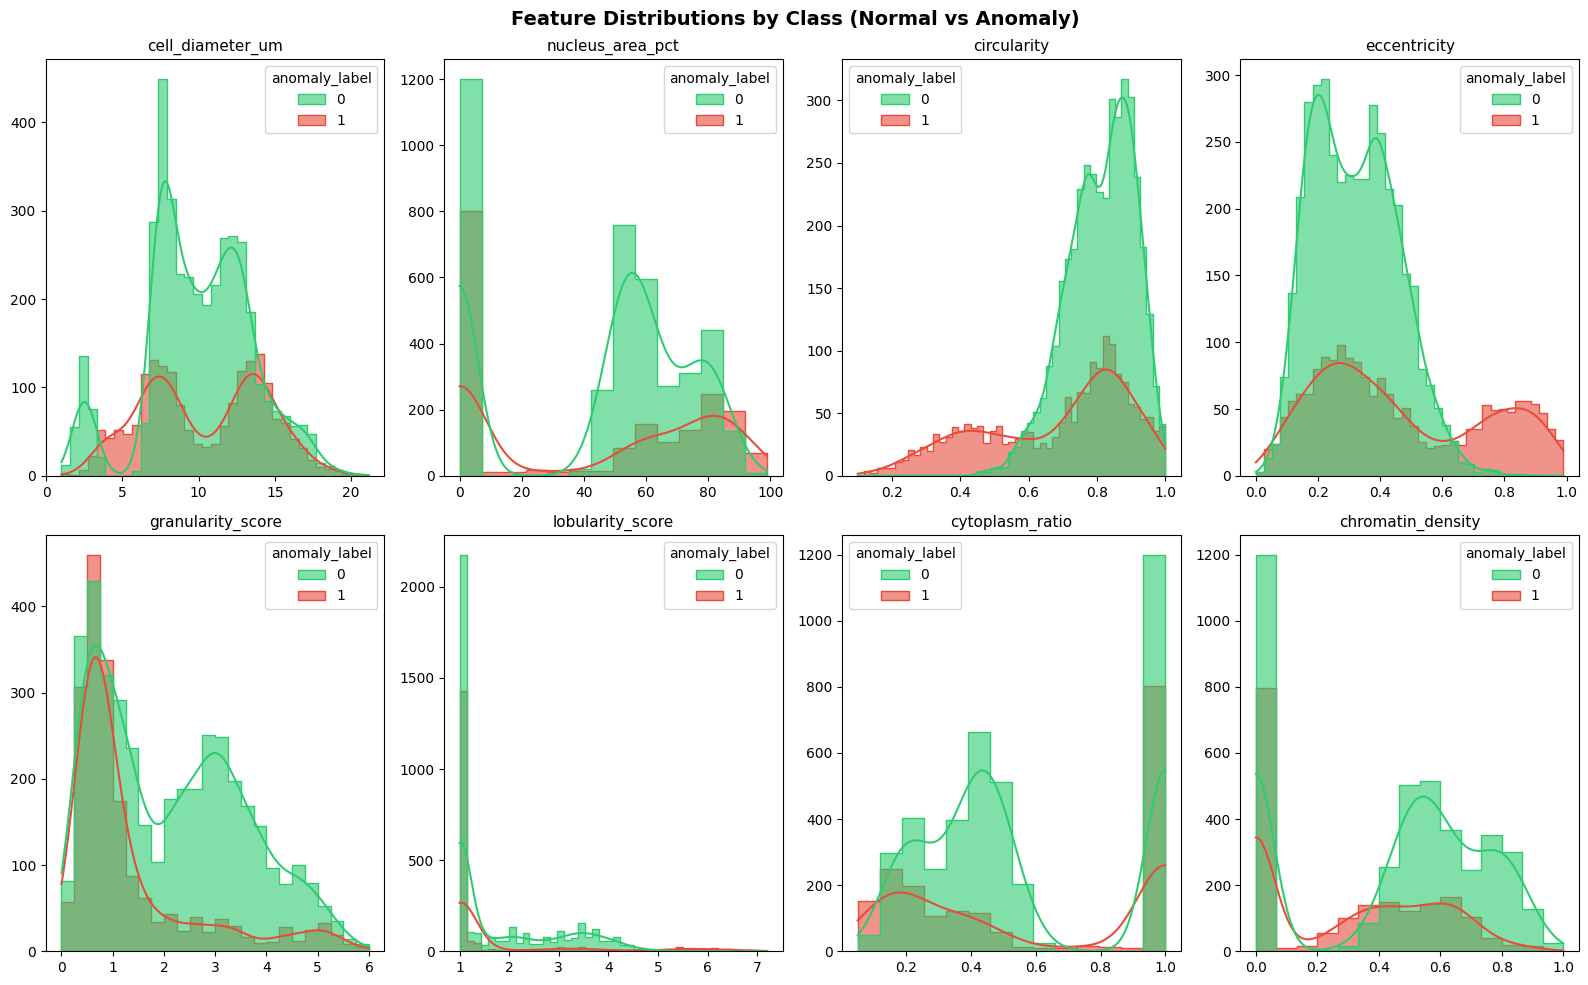

In [99]:
# important morphological features
key_features = [
    'cell_diameter_um', 'nucleus_area_pct', 'circularity',
    'eccentricity', 'granularity_score', 'lobularity_score',
    'cytoplasm_ratio', 'chromatin_density'
]

plt.figure(figsize=(16, 10))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 4, i)
    sns.histplot(data=df_clean, x=col, hue='anomaly_label',
                 palette=['#2ecc71', '#e74c3c'], kde=True, element='step', alpha=0.6)
    plt.title(col, fontsize=11)
    plt.xlabel('')
    plt.ylabel('')

plt.suptitle('Feature Distributions by Class (Normal vs Anomaly)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

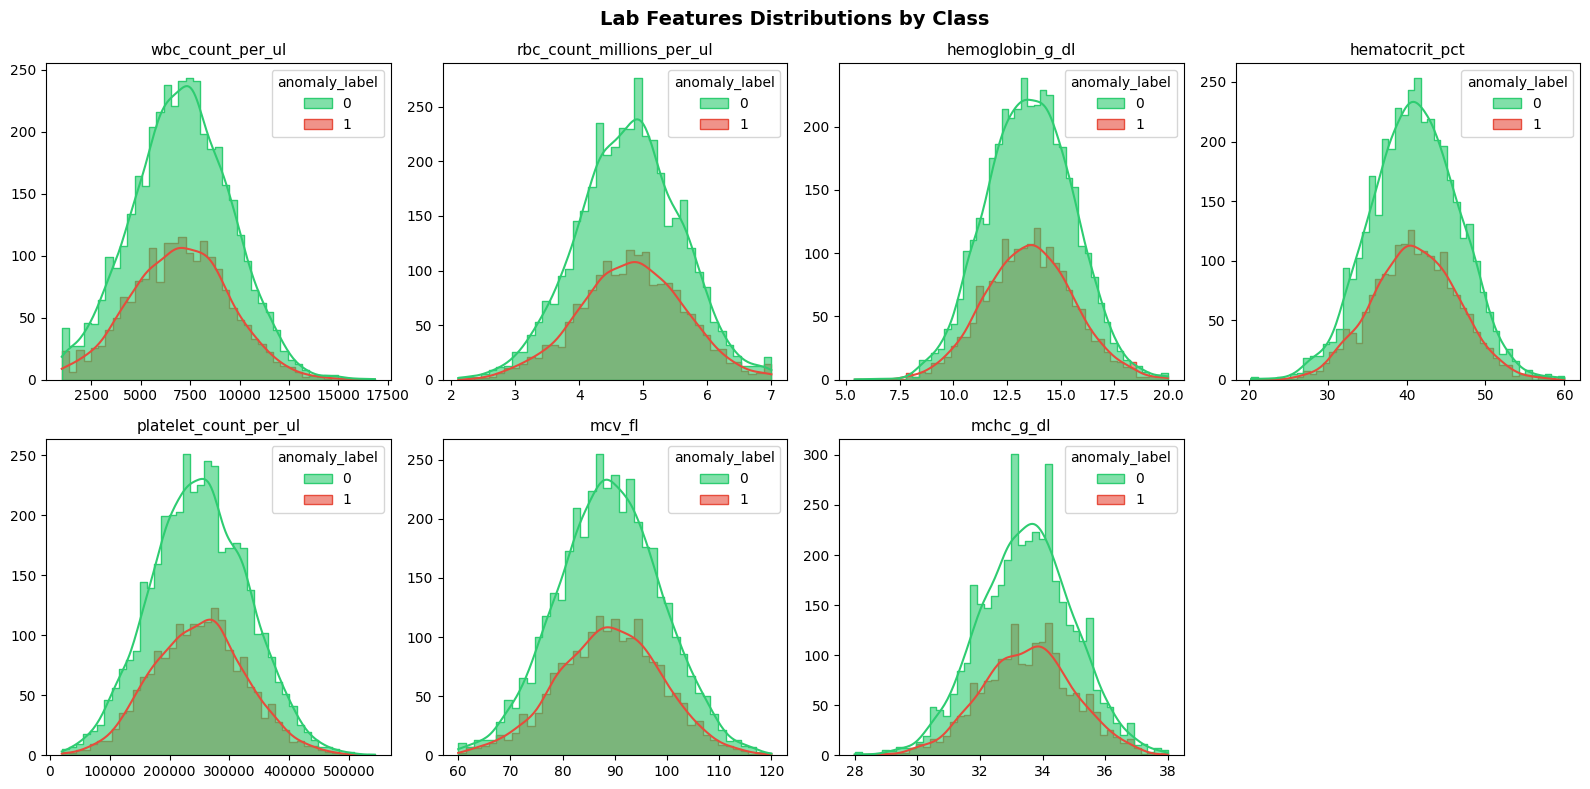

In [100]:
# Lab blood test features
lab_features = [
    'wbc_count_per_ul', 'rbc_count_millions_per_ul',
    'hemoglobin_g_dl', 'hematocrit_pct',
    'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl'
]

plt.figure(figsize=(16, 8))
for i, col in enumerate(lab_features, 1):
    plt.subplot(2, 4, i)
    sns.histplot(data=df_clean, x=col, hue='anomaly_label',
                 palette=['#2ecc71', '#e74c3c'], kde=True, element='step', alpha=0.6)
    plt.title(col, fontsize=11)
    plt.xlabel('')
    plt.ylabel('')

plt.suptitle('Lab Features Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

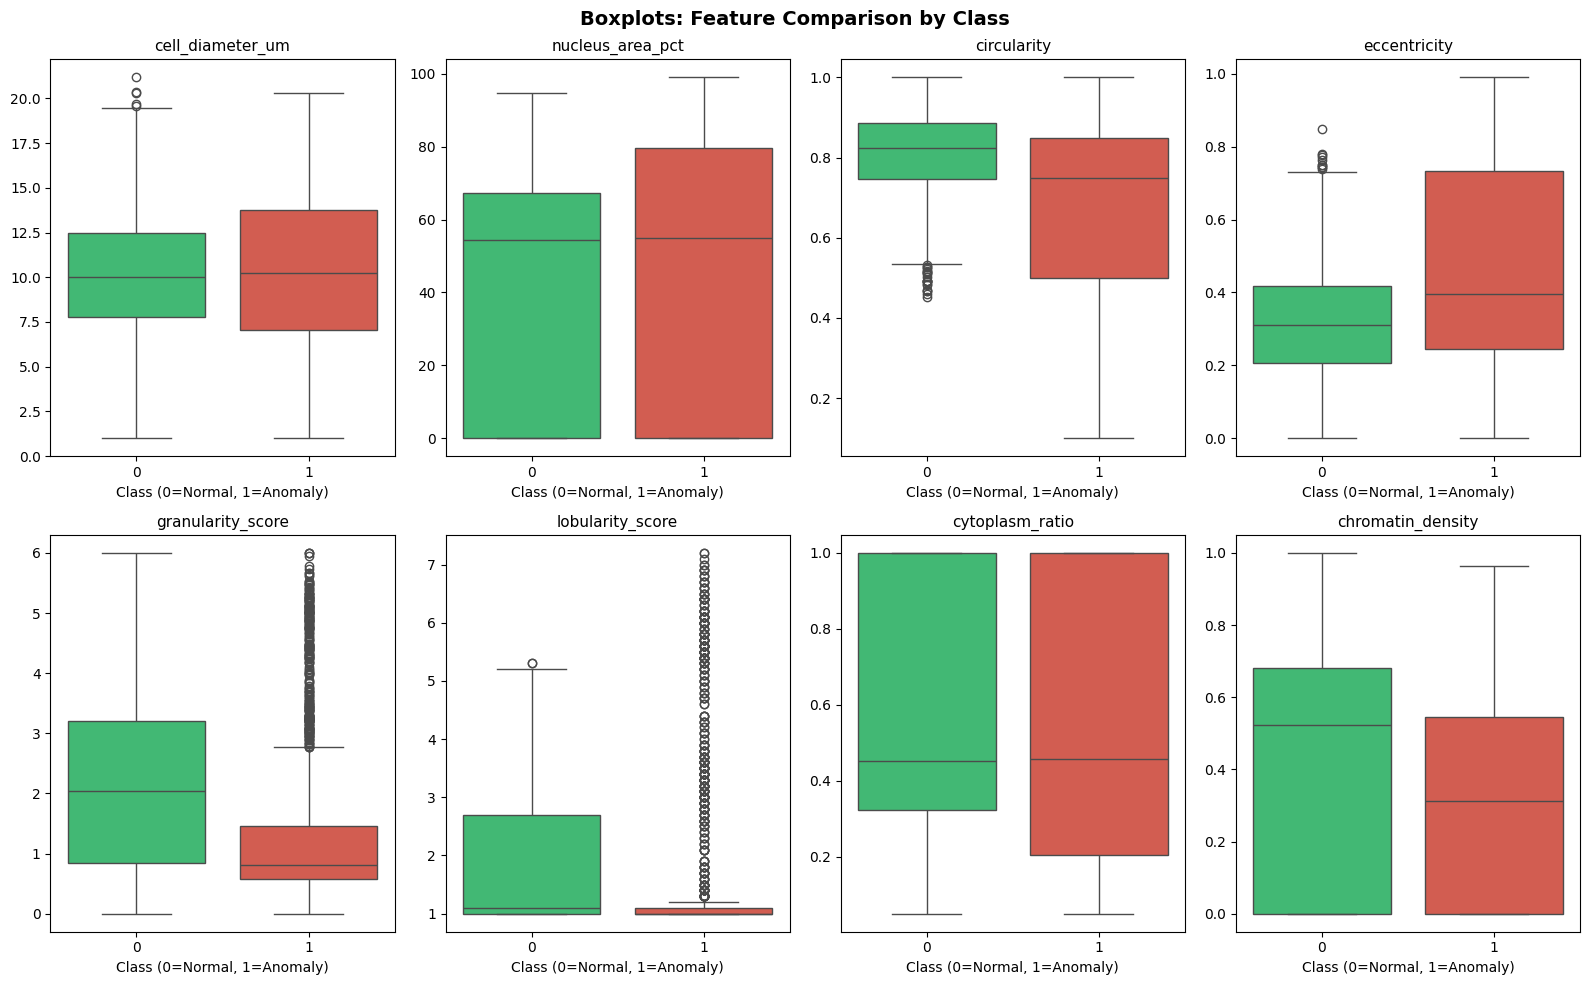

In [101]:
# Boxplots للمقارنة بين Normal و Anomaly
plt.figure(figsize=(16, 10))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(data=df_clean, x='anomaly_label', y=col,
                palette=['#2ecc71', '#e74c3c'])
    plt.title(col, fontsize=11)
    plt.xlabel('Class (0=Normal, 1=Anomaly)')
    plt.ylabel('')

plt.suptitle('Boxplots: Feature Comparison by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Outlier Inspection

Inspect outliers using the IQR method.  
Extreme values may represent real observations, so **no rows are removed**.

In [102]:
numeric_cols = FEATURE_ORDER.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col:28s}: {len(outliers):4d} ({len(outliers)/len(df_clean)*100:.1f}%)")

cell_diameter_um            :    1 (0.0%)
nucleus_area_pct            :    0 (0.0%)
chromatin_density           :    0 (0.0%)
cytoplasm_ratio             :    0 (0.0%)
circularity                 :  394 (6.7%)
eccentricity                :  304 (5.2%)
granularity_score           :    0 (0.0%)
lobularity_score            :  271 (4.6%)
membrane_smoothness         :  100 (1.7%)
cell_area_px                :    4 (0.1%)
perimeter_px                :    7 (0.1%)
mean_r                      :   32 (0.5%)
mean_g                      :    8 (0.1%)
mean_b                      :    0 (0.0%)
stain_intensity             :    3 (0.1%)
wbc_count_per_ul            :   23 (0.4%)
rbc_count_millions_per_ul   :   43 (0.7%)
hemoglobin_g_dl             :   39 (0.7%)
hematocrit_pct              :   34 (0.6%)
platelet_count_per_ul       :   25 (0.4%)
mcv_fl                      :   32 (0.5%)
mchc_g_dl                   :   35 (0.6%)
magnification_x             :    0 (0.0%)
image_resolution_px         :    0

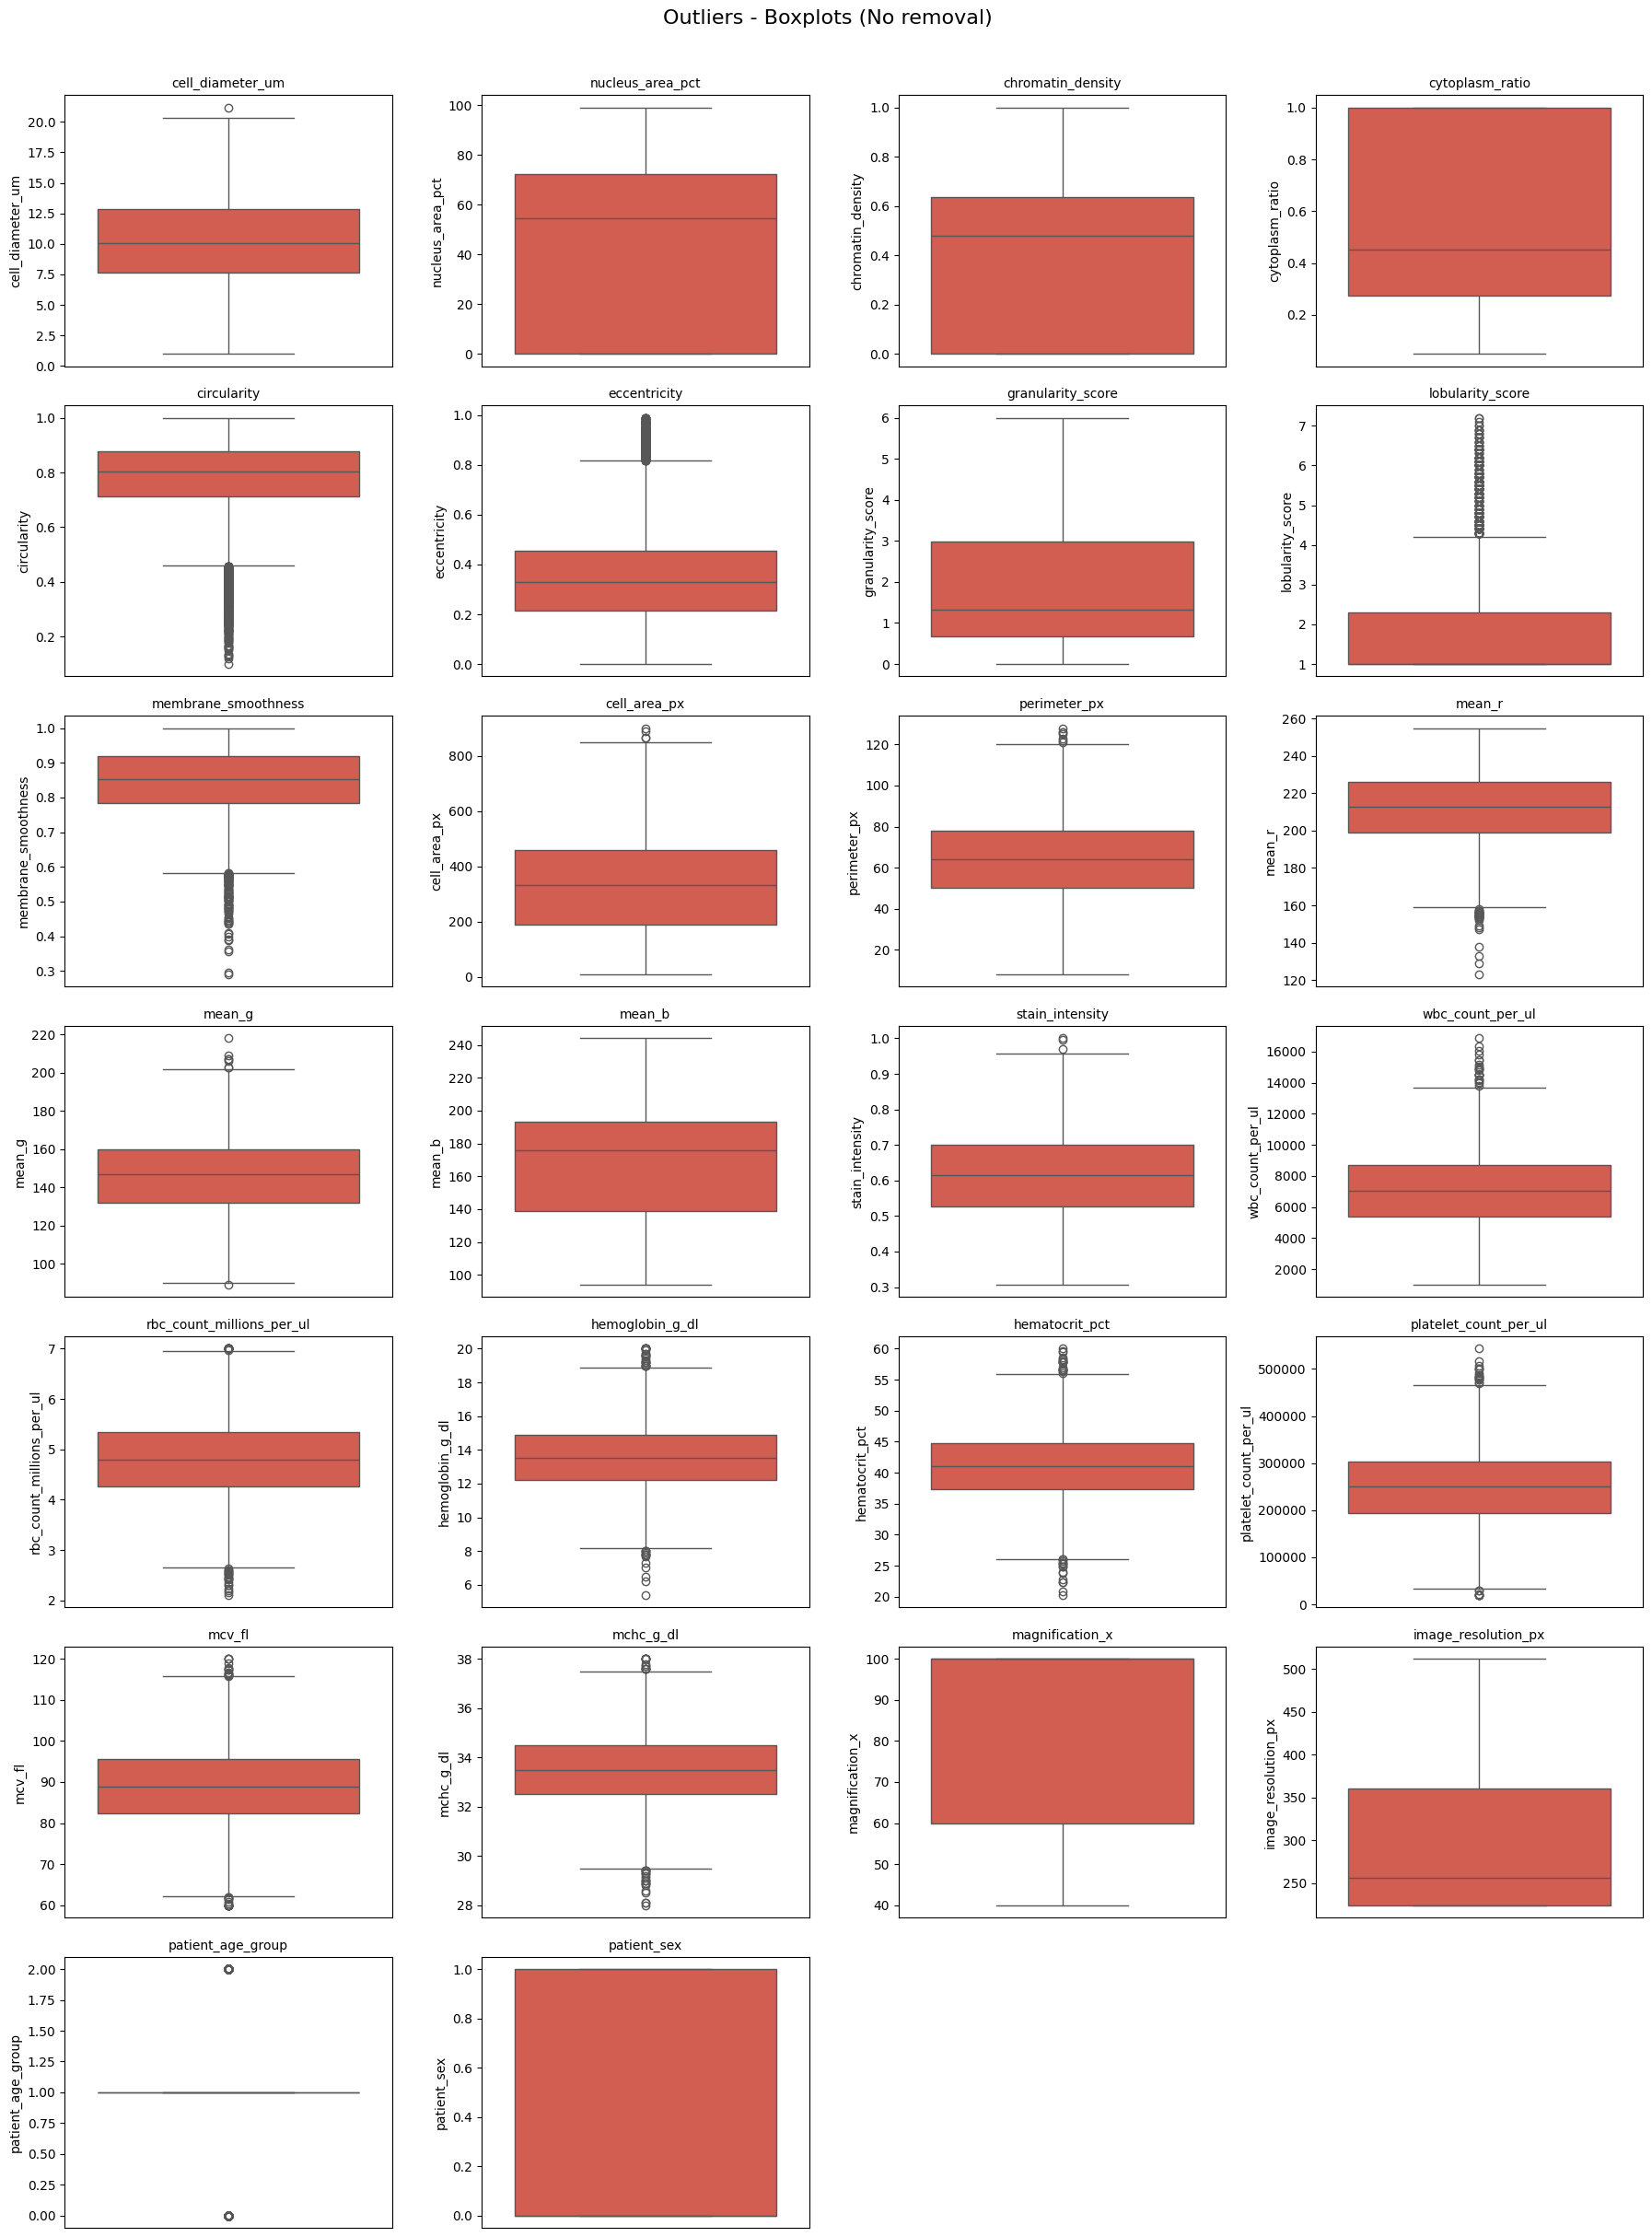

In [103]:
plt.figure(figsize=(18, 24))
num_cols = 4
num_rows = len(numeric_cols) // num_cols + (len(numeric_cols) % num_cols > 0)

for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows, num_cols, i+1)
    sns.boxplot(y=df_clean[col], color='#e74c3c')
    plt.title(col, fontsize=10)
    plt.xticks([])

plt.suptitle('Outliers - Boxplots (No removal)', y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

## 10. Correlation Analysis

Visualize the correlation between numerical features using a heatmap.

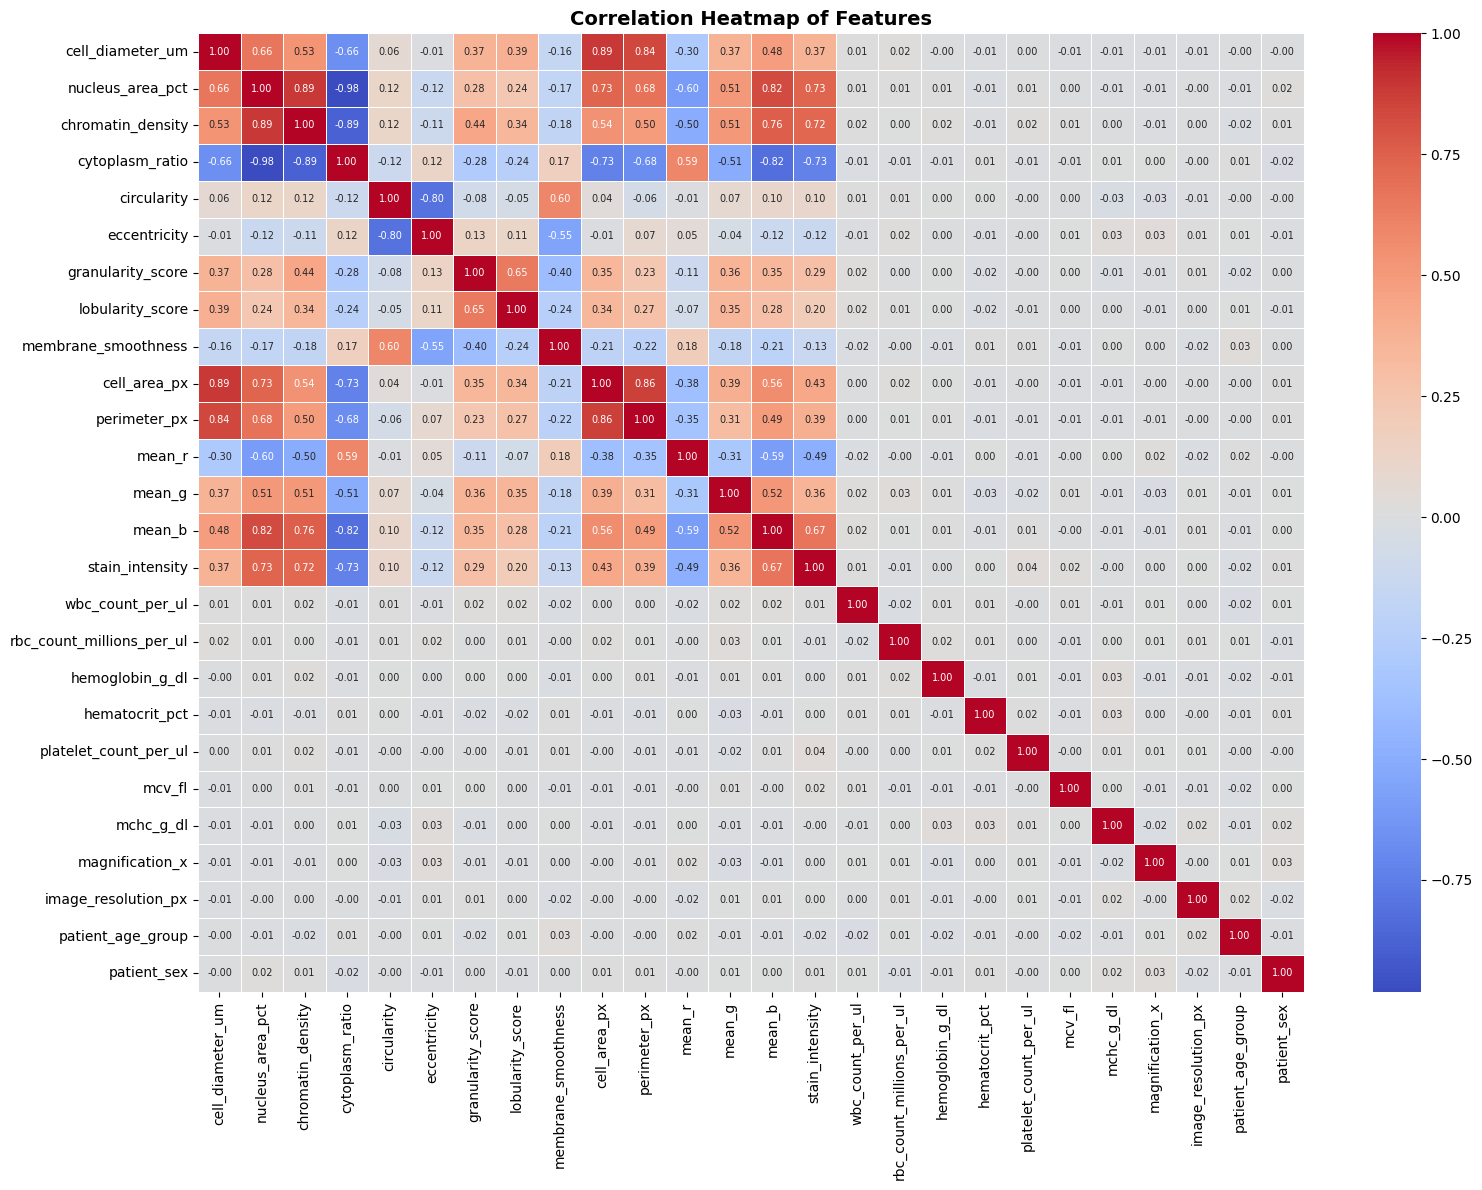

In [104]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    df_clean[FEATURE_ORDER].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    annot_kws={'size': 7}
)
plt.title('Correlation Heatmap of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Prepare Features and Target + Train-Test Split

Separate features (X) and target (y), then perform a stratified train-test split (80/20) to preserve class balance.

In [105]:
X = df_clean[FEATURE_ORDER]
y = df_clean['anomaly_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Class balance (Train):", y_train.value_counts(normalize=True).round(2).values)

Train shape: (4704, 26)
Test shape : (1176, 26)
Class balance (Train): [0.68 0.32]


## 12. Feature Scaling

Fit `StandardScaler` on the training data only, then transform both training and test sets.  
This prevents information leakage from the test set.

In [106]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 13. Model Training

Train multiple classification models and evaluate them on the test set.

In [107]:
#XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

print("XGBoost")
print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_xgb), 4))
print(classification_report(y_test, y_pred_xgb))

XGBoost
Accuracy : 0.9762
Recall   : 0.9388
Precision: 0.986
F1 Score : 0.9619
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       800
           1       0.99      0.94      0.96       376

    accuracy                           0.98      1176
   macro avg       0.98      0.97      0.97      1176
weighted avg       0.98      0.98      0.98      1176



In [108]:
#Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy : 0.9651
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       800
           1       1.00      0.89      0.94       376

    accuracy                           0.97      1176
   macro avg       0.98      0.95      0.96      1176
weighted avg       0.97      0.97      0.96      1176



In [109]:
#Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

print("Gradient Boosting")
print("Accuracy :", round(accuracy_score(y_test, y_pred_gb), 4))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
Accuracy : 0.977
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       800
           1       0.98      0.94      0.96       376

    accuracy                           0.98      1176
   macro avg       0.98      0.97      0.97      1176
weighted avg       0.98      0.98      0.98      1176



In [110]:
#Decision Tree
dt = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print("Decision Tree")
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 4))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy : 0.9286
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       800
           1       0.91      0.87      0.89       376

    accuracy                           0.93      1176
   macro avg       0.92      0.91      0.92      1176
weighted avg       0.93      0.93      0.93      1176



In [111]:
#AdaBoost
ada = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)

print("AdaBoost")
print("Accuracy :", round(accuracy_score(y_test, y_pred_ada), 4))
print(classification_report(y_test, y_pred_ada))

AdaBoost
Accuracy : 0.9141
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       800
           1       0.95      0.77      0.85       376

    accuracy                           0.91      1176
   macro avg       0.93      0.88      0.90      1176
weighted avg       0.92      0.91      0.91      1176



In [112]:
#SVM
svc = SVC(
    kernel='rbf',
    C=1.0,
    class_weight='balanced',
    probability=True,
    random_state=42
)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)

print("SVM")
print("Accuracy :", round(accuracy_score(y_test, y_pred_svc), 4))
print(classification_report(y_test, y_pred_svc))

SVM
Accuracy : 0.9379
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       800
           1       0.98      0.82      0.89       376

    accuracy                           0.94      1176
   macro avg       0.95      0.91      0.93      1176
weighted avg       0.94      0.94      0.94      1176



In [113]:
#Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 4))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy : 0.7849
              precision    recall  f1-score   support

           0       0.86      0.81      0.84       800
           1       0.65      0.72      0.68       376

    accuracy                           0.78      1176
   macro avg       0.75      0.77      0.76      1176
weighted avg       0.79      0.78      0.79      1176



In [114]:
#KNN
knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    n_jobs=-1
)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN")
print("Accuracy :", round(accuracy_score(y_test, y_pred_knn), 4))
print(classification_report(y_test, y_pred_knn))

KNN
Accuracy : 0.9073
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       800
           1       0.97      0.73      0.83       376

    accuracy                           0.91      1176
   macro avg       0.93      0.86      0.89      1176
weighted avg       0.91      0.91      0.90      1176



## Finding Optimal K for KNN

Test different values of K (1 to 20) and select the one with the highest test accuracy.

In [115]:
scores = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
    model.fit(X_train_scaled, y_train)
    model_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, model_pred)
    scores.append(accuracy)

best_k = np.argmax(scores) + 1
print("Best K:", best_k)
print("Best Accuracy:", round(max(scores), 4))

Best K: 10
Best Accuracy: 0.9124


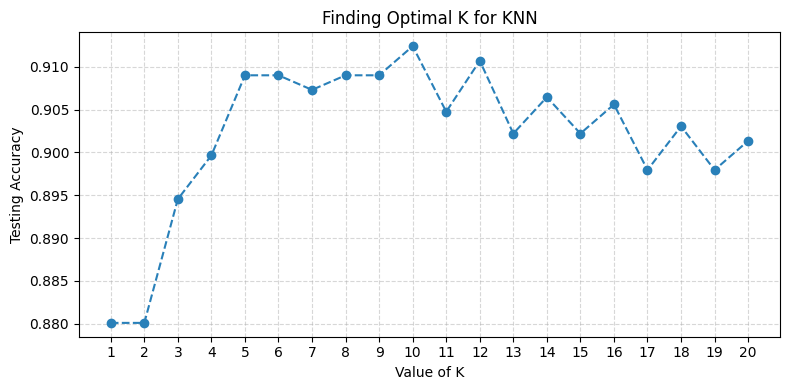

In [116]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, scores, marker='o', linestyle='--', color='#2980b9')
plt.xlabel('Value of K')
plt.ylabel('Testing Accuracy')
plt.title('Finding Optimal K for KNN')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [117]:
# KNN with Best K
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    n_jobs=-1
)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN (Best K =", best_k, ")")
print("Accuracy :", round(accuracy_score(y_test, y_pred_knn), 4))
print(classification_report(y_test, y_pred_knn))

KNN (Best K = 10 )
Accuracy : 0.9124
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       800
           1       0.99      0.73      0.84       376

    accuracy                           0.91      1176
   macro avg       0.94      0.86      0.89      1176
weighted avg       0.92      0.91      0.91      1176



In [118]:
#Naive Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

print("Naive Bayes")
print("Accuracy :", round(accuracy_score(y_test, y_pred_nb), 4))
print(classification_report(y_test, y_pred_nb))

Naive Bayes
Accuracy : 0.7789
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       800
           1       0.71      0.52      0.60       376

    accuracy                           0.78      1176
   macro avg       0.76      0.71      0.72      1176
weighted avg       0.77      0.78      0.77      1176



## 14. Model Comparison

Compare all trained models using Accuracy, Precision, Recall, and F1-Score.

In [119]:
results = []
preds = {
    'XGBoost': y_pred_xgb,
    'Gradient Boosting': y_pred_gb,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svc,
    'Decision Tree': y_pred_dt,
    'KNN': y_pred_knn,
    'AdaBoost': y_pred_ada,
    'Logistic Regression': y_pred_lr,
    'Naive Bayes': y_pred_nb
}

for name, pred in preds.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print(results_df.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score
  Gradient Boosting    0.9770     0.9834  0.9441    0.9634
            XGBoost    0.9762     0.9860  0.9388    0.9619
      Random Forest    0.9651     1.0000  0.8910    0.9423
                SVM    0.9379     0.9810  0.8218    0.8944
      Decision Tree    0.9286     0.9056  0.8670    0.8859
           AdaBoost    0.9141     0.9479  0.7739    0.8521
                KNN    0.9124     0.9928  0.7314    0.8423
Logistic Regression    0.7849     0.6468  0.7207    0.6818
        Naive Bayes    0.7789     0.7117  0.5186    0.6000


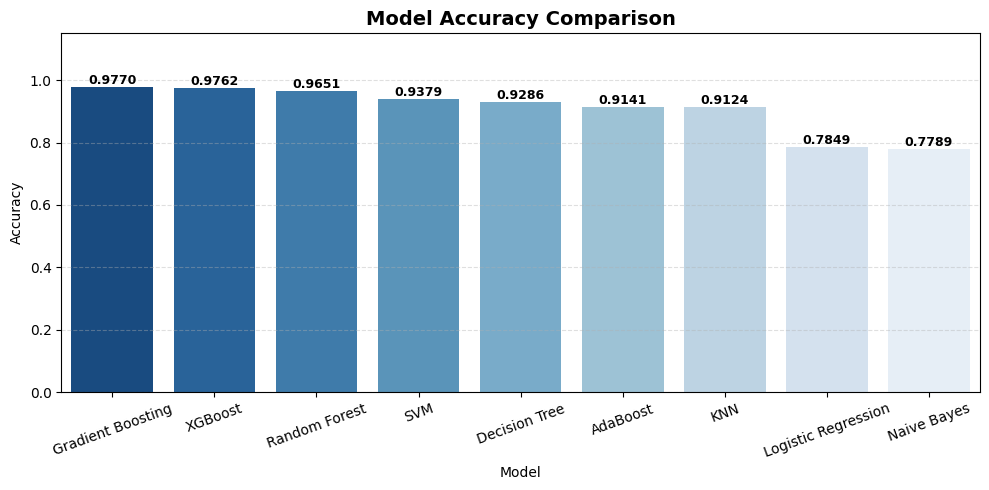

In [120]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=results_df, x='Model', y='Accuracy', palette='Blues_r')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1.15)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.4f}',
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Overfitting Check

Compare Train Accuracy vs Test Accuracy for each model to detect overfitting.

In [121]:
trained_models = {
    'XGBoost': xgb,
    'Gradient Boosting': gb,
    'Random Forest': rf,
    'SVM': svc,
    'Decision Tree': dt,
    'KNN': knn,
    'AdaBoost': ada,
    'Logistic Regression': log_reg,
    'Naive Bayes': nb
}

overfit_rows = []
for name, model in trained_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc  = accuracy_score(y_test, model.predict(X_test_scaled))
    overfit_rows.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Diff': train_acc - test_acc
    })

overfit_df = pd.DataFrame(overfit_rows).sort_values(by='Test Acc', ascending=False)
print(overfit_df.round(4).to_string(index=False))

              Model  Train Acc  Test Acc    Diff
  Gradient Boosting     1.0000    0.9770  0.0230
            XGBoost     1.0000    0.9762  0.0238
      Random Forest     0.9853    0.9651  0.0202
                SVM     0.9575    0.9379  0.0196
      Decision Tree     0.9713    0.9286  0.0427
           AdaBoost     0.9199    0.9141  0.0057
                KNN     1.0000    0.9124  0.0876
Logistic Regression     0.7938    0.7849  0.0089
        Naive Bayes     0.7719    0.7789 -0.0070


## 16. Confusion Matrices (Top 3 Models)

Display confusion matrices for the three best performing models.

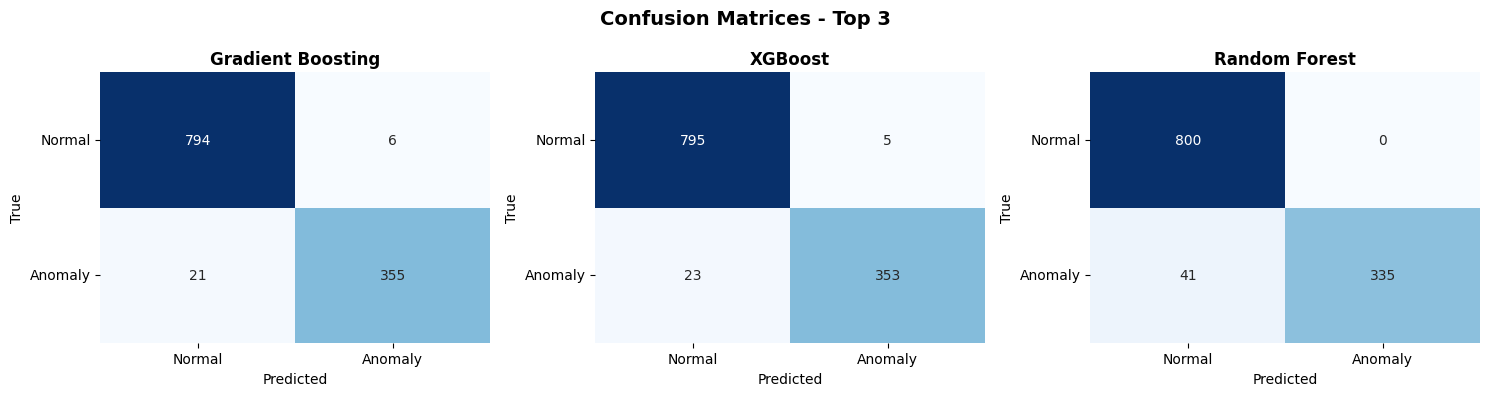

In [122]:
top3 = results_df['Model'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_test, preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticklabels(['Normal', 'Anomaly'])
    ax.set_yticklabels(['Normal', 'Anomaly'], rotation=0)

plt.suptitle('Confusion Matrices - Top 3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Feature Importance

Calculate and visualize feature importance using Permutation Importance and native XGBoost importance.

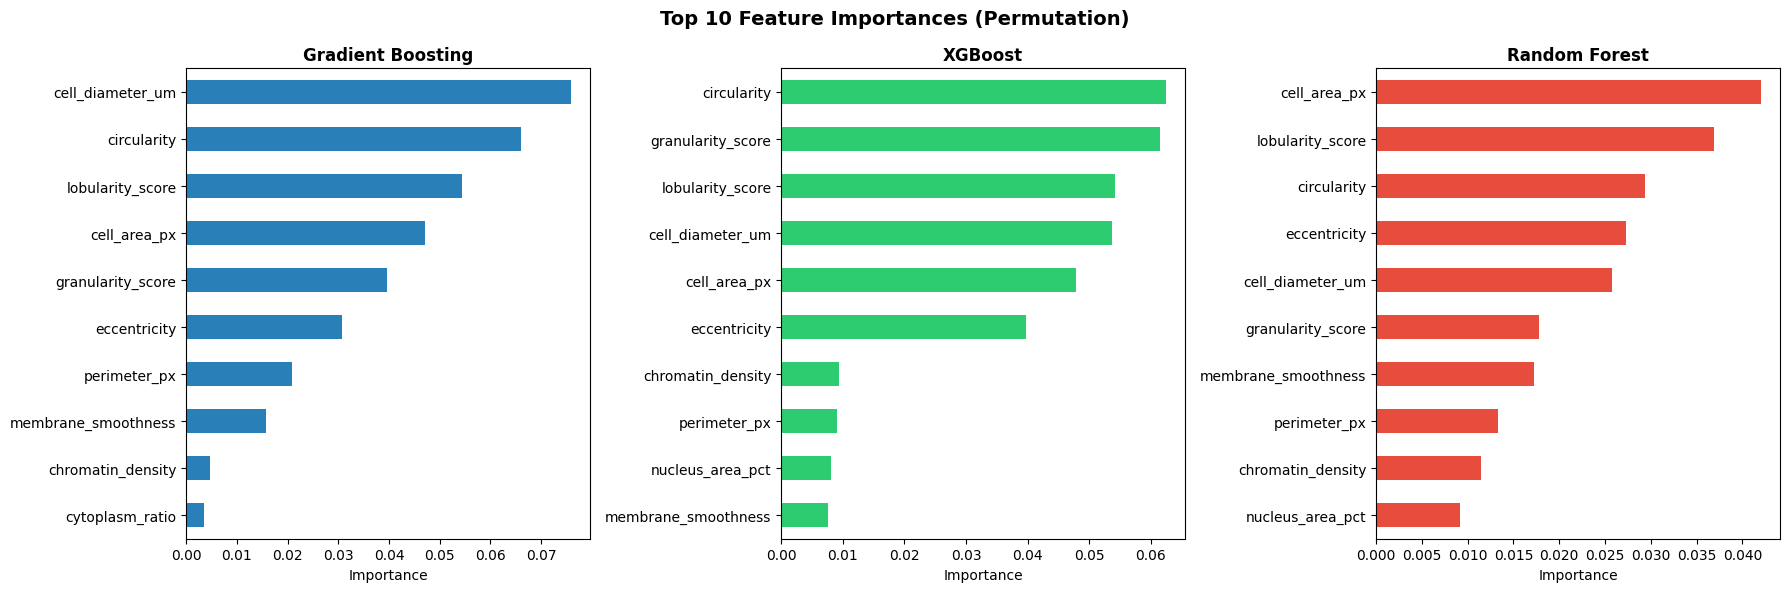

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#2980b9', '#2ecc71', '#e74c3c']

for ax, name, color in zip(axes, top3, colors):
    result = permutation_importance(
        trained_models[name], X_test_scaled, y_test,
        n_repeats=10, random_state=42, scoring='accuracy', n_jobs=-1
    )
    feat_imp = pd.Series(result.importances_mean, index=FEATURE_ORDER).nlargest(10).sort_values()
    feat_imp.plot(kind='barh', ax=ax, color=color)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Top 10 Feature Importances (Permutation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

eccentricity         0.1094
circularity          0.1053
lobularity_score     0.1033
nucleus_area_pct     0.1015
cell_area_px         0.0985
cytoplasm_ratio      0.0863
perimeter_px         0.0666
chromatin_density    0.0593
cell_diameter_um     0.0518
granularity_score    0.0423
dtype: float32


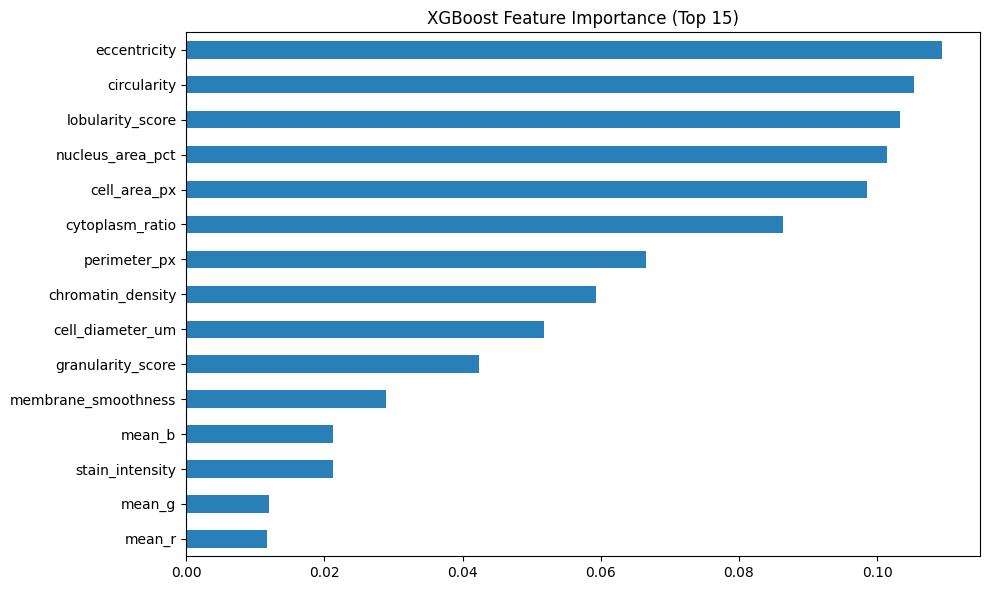

In [124]:
xgb_imp = pd.Series(xgb.feature_importances_, index=FEATURE_ORDER).sort_values(ascending=False)
print(xgb_imp.head(10).round(4))

plt.figure(figsize=(10, 6))
xgb_imp.head(15).sort_values().plot(kind='barh', color='#2980b9')
plt.title('XGBoost Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

## 18. Cross-Validation

Perform 5-Fold Cross-Validation on the best model (XGBoost) to confirm performance stability.

In [130]:
cv_scores = cross_val_score(xgb, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("CV Scores:", cv_scores.round(4))
print("Mean CV Accuracy:", round(cv_scores.mean(), 4), "(+/-", round(cv_scores.std()*2, 4), ")")

CV Scores: [0.9671 0.9724 0.9649 0.9777 0.9649]
Mean CV Accuracy: 0.9694 (+/- 0.0099 )


## 19. Save Artifacts

Save the best model, the scaler, and the feature order for deployment.

In [132]:
import joblib
import xgboost as xgb_lib
import sklearn

print("XGBoost version:", xgb_lib.__version__)
print("sklearn version:", sklearn.__version__)
print("Model type:", type(xgb))
print("n_features:", len(FEATURE_ORDER))

joblib.dump(xgb, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(FEATURE_ORDER, "feature_order.pkl")

xgb.get_booster().save_model("best_model.json")

m_test = joblib.load("best_model.pkl")
print("Reload OK:", type(m_test))
print("Predict test shape check:", m_test.n_features_in_)

print("\n=== DONE - download these files ===")
print("  best_model.pkl")
print("  best_model.json")
print("  scaler.pkl")
print("  feature_order.pkl")

XGBoost version: 3.4.1
sklearn version: 1.6.1
Model type: <class 'xgboost.sklearn.XGBClassifier'>
n_features: 26
Reload OK: <class 'xgboost.sklearn.XGBClassifier'>
Predict test shape check: 26

=== DONE - download these files ===
  best_model.pkl
  best_model.json
  scaler.pkl
  feature_order.pkl


## 20. Conclusion

- 26 clean features were used (no data leakage).
- Sex encoding: **F = 0** , **M = 1**
- Age encoding: Pediatric = 0 , Adult = 1 , Elderly = 2
- Best model: **XGBoost**
- Artifacts saved for Streamlit App and FastAPI deployment.

**Important for deployment:**
1. Use the exact `FEATURE_ORDER` list.
2. Use the same encoding (`F=0`, `M=1`).
3. Load `scaler.pkl` and `best_model.pkl`.